<a href="https://colab.research.google.com/github/anishb77/Tensorflow-Projects/blob/main/Graduation_Predictor_Charlotte_Mecklenburg_Schools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that I am starting to get practice with cleaning data and manipulating it to make it usable, I want to try to make a project that I don't think exists as of making this, and that could actually solve a problem. I want to use past data/trends to try and predict the graduation percentage of high schools in my county (Charlotte Mecklenburg Schools). Making such a model could help evaluate risk and determine which schools need the most attention. I already found some useful data on the CMS website that I will bring in now.

In [67]:
import sklearn
import numpy as np
import pandas as pd
import requests
import io

In [68]:
#Disclaimer: I used AI to figure out how to load data from my Github

def get_data(file_name, columns=[]):
    repo_url = "https://raw.githubusercontent.com/anishb77/Tensorflow-Projects/main/cms-dropout-predictor-data/"
    response = requests.get(repo_url + file_name)
    return pd.read_excel(io.BytesIO(response.content), usecols=columns)

cohort_graduation_rate = get_data("rcd_acc_cgr.xlsx", columns=["agency_code", "subgroup", "pct", "year", "cgr_type"])
percent_econ_disadvantaged_students = get_data("rcd_acc_eds.xlsx", columns=["agency_code", "pct_eds", "year"])
evaas_growth = get_data("rcd_acc_eg.xlsx", columns=["agency_code", "subgroup", "eg_index", "year"])
chronic_absent = get_data("rcd_chronic_absent.xlsx", columns=["agency_code", "subgroup", "pct", "year"])
school_funds = get_data("rcd_funds2.xlsx", columns=["agency_code", "total_ppe", "year", "expenditure_category"])
incidents = get_data("rcd_inc2.xlsx", columns=["agency_code", "subgroup", "iss_per1000", "exp_per1000", "year"])
school_location = get_data("rcd_location.xlsx", columns=["agency_code", "category_code", "year"])

In [69]:
school_location = school_location[school_location["category_code"] == "H"] #filters for high schools
school_location = school_location.drop(columns = ["category_code"])
school_location.describe()

,year
count,9543.000000
mean,2015.254742
std,5.418512
min,2006.000000
25%,2011.000000
50%,2015.000000
75%,2020.000000
max,2024.000000


Now that I have the columns I need separately, I need to somehow match columns from the other dataframes to school_location based on the agency code. This will create a full dataset that can actually be trained on (although a tiny one at that, I only have 9543 datapoints so far and this will go down as I filter; I'm worrying that such a small dataset along with some old trends from 2018 might make the model suboptimal, but I have no choice but to test it)

First, I'll change the names of some of the columns so they're more clear and filter the subgroup for all.

In [70]:
def clean_rename(df, rename):
  df = df[df["subgroup"] == "ALL"]
  df = df.rename(columns=rename)
  df = df.drop(columns=["subgroup"])
  return df

cohort_graduation_rate = clean_rename(cohort_graduation_rate, {"pct": "graduation_percent"})
evaas_growth = clean_rename(evaas_growth, {"eg_index": "evaas_growth_index"})
chronic_absent = clean_rename(chronic_absent, {"pct": "chronic_absent_percent"})
incidents = clean_rename(incidents, {})

In [71]:
#Ended up having to go back and remove redundancies so the merging would work later on...

cohort_graduation_rate = cohort_graduation_rate[cohort_graduation_rate["cgr_type"] == "STD"]
cohort_graduation_rate = cohort_graduation_rate.drop(columns=["cgr_type"])
print(cohort_graduation_rate.count())

school_funds = school_funds[school_funds["expenditure_category"] == "TOTAL"]
school_funds = school_funds.drop(columns=["expenditure_category"])
print(school_funds.count())

year                  12830
agency_code           12830
graduation_percent    12830
dtype: int64
year           15921
agency_code    15921
total_ppe      15921
dtype: int64


Nice, I should be ready to match all the columns into one dataframe using merge.

In [72]:
school_location = pd.merge(left=school_location, right= cohort_graduation_rate, how="left", on=["year", "agency_code"])
school_location = pd.merge(left=school_location, right= percent_econ_disadvantaged_students, how="left", on=["year", "agency_code"])
school_location = pd.merge(left=school_location, right= evaas_growth, how="left", on=["year", "agency_code"])
school_location = pd.merge(left=school_location, right= chronic_absent, how="left", on=["year", "agency_code"])
school_location = pd.merge(left=school_location, right= school_funds, how="left", on=["year", "agency_code"])
school_location = pd.merge(left=school_location, right= incidents, how="left", on=["year", "agency_code"])

school_location.drop_duplicates(subset=["agency_code", "year"])
school_location.head()

,year,agency_code,graduation_percent,pct_eds,evaas_growth_index,chronic_absent_percent,total_ppe,iss_per1000,exp_per1000
0,2024,010303,95.0,33.9,5.46,0.050000,9329.23,0.0000,0.0
1,2024,010311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,010324,92.5,57.6,3.95,0.335871,11229.41,481.0009,0.0
3,2024,010348,76.6,66.5,-1.72,0.427500,14197.58,206.7511,0.0
4,2024,010360,71.6,73.9,0.70,0.634483,13022.37,123.0964,0.0


In [73]:
school_location = school_location.dropna()
print(school_location.head())
school_location.count()

   year agency_code  graduation_percent  pct_eds  evaas_growth_index  \
0  2024      010303                95.0     33.9                5.46   
2  2024      010324                92.5     57.6                3.95   
3  2024      010348                76.6     66.5               -1.72   
4  2024      010360                71.6     73.9                0.70   
5  2024      010388                92.0     47.1                0.47   

   chronic_absent_percent  total_ppe  iss_per1000  exp_per1000  
0                0.050000    9329.23       0.0000          0.0  
2                0.335871   11229.41     481.0009          0.0  
3                0.427500   14197.58     206.7511          0.0  
4                0.634483   13022.37     123.0964          0.0  
5                0.506849   11909.27     185.1852          0.0  


,0
year,1937
agency_code,1937
graduation_percent,1937
pct_eds,1937
evaas_growth_index,1937
chronic_absent_percent,1937
total_ppe,1937
iss_per1000,1937
exp_per1000,1937


1937 columns...that's so low, I'm definitely not making a good, highly accurate model. Hopefully I can at least discover trends and see which features contribute the most to graduation.

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

y = school_location["graduation_percent"]
x = school_location.drop(columns=["graduation_percent", "agency_code", "year"]) # Drop 'agency_code' column

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 67)
model = RandomForestRegressor(random_state = 67)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=67)

In [75]:
predictions = model.predict(x_test)
error = root_mean_squared_error(y_test, predictions)
error

6.107356285787365

Considering that the graduation rate varies a lot, this is decent (I'm pretty sure this means an average deviation of 6%). However, I am curious as to what contributes to this the most since it could be useful insight. Here's some AI code that visualizes it as a plot!

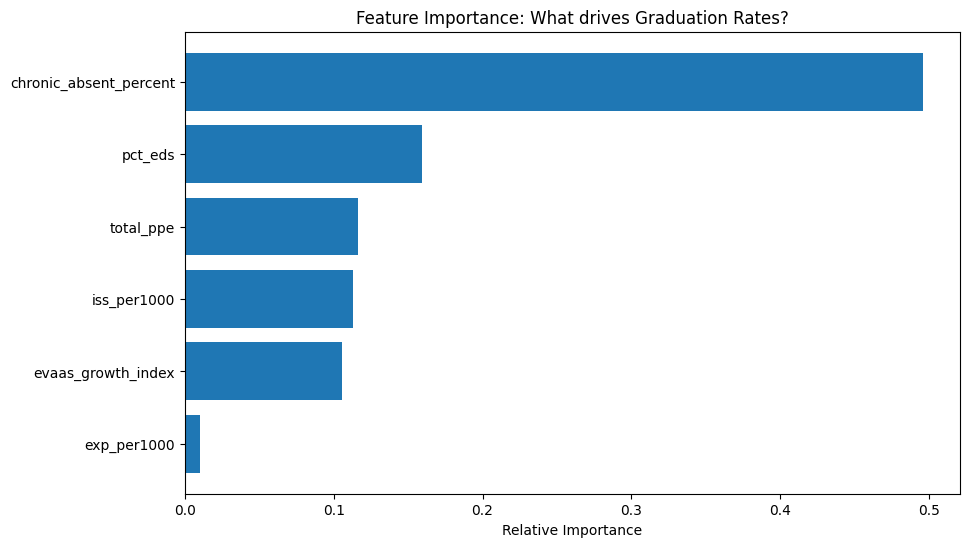

In [76]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)
features = x_train.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance: What drives Graduation Rates?")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Whoa, this is really cool! It really shows how behavioral trends can actually correlate to the risk of graduation and how much chronic absenteeism really matters in predicting the future of a student. Of course, it's worth noting that the other features had a much weaker correlation and expelling was useless since it's a rare scenario that doesn't apply to a majority of students. Hopefully this helps show initial insight into the graduation rates of schools in my county of Charlotte Mecklenburg Schools! With that, here's a last minute script so you can test values for yourself!

In [85]:
while True:
  inputs = []

  for feature in x_train.columns:
    inputs.append(float(input(f"Input a value for {feature}: ")))

  prediction = model.predict([inputs])
  print(f"Predicted graduation percentage: {round(prediction[0], ndigits=2)}%")

  if input("Enter \"y\" to try again, any other value to cancel: ") != "y":
    break

Input a value for pct_eds: 2
Input a value for evaas_growth_index: 0.2
Input a value for chronic_absent_percent: 5
Input a value for total_ppe: 20000
Input a value for iss_per1000: 2
Input a value for exp_per1000: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Predicted graduation percentage: 41.02%
Enter "y" to try again, any other value to cancel: c
